In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)

import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.manual_seed(42)
np.random.seed(42)


Device: cuda


In [ ]:
import pandas as pd

t1 = pd.read_excel("capstone_dataset.xlsx", sheet_name="Supplementary Table 1", header=3)
t2 = pd.read_excel("capstone_dataset.xlsx", sheet_name="Supplementary Table 2", header=3)

def clean_cols(df):
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("(", "")
        .str.replace(")", "")
        .str.replace("/", "_")
    )
    return df

t1 = clean_cols(t1)
t2 = clean_cols(t2)

seq_col = None
for c in t1.columns:
    if "sequence" in c:
        seq_col = c
        break

t1 = t1[["gene", "gc", "strand", seq_col]].dropna()
t1 = t1.rename(columns={seq_col: "sequence"})

t2 = t2.rename(columns={"promoter": "gene"}).dropna()

data = pd.merge(t1, t2, on="gene", how="inner")
print("Merged shape:", data.shape)
display(data.head())





Merged shape: (67860, 11)


,gene,gc,strand,sequence,species,"no_enhancer,_dark,\ntobacco_leaves","no_enhancer,_dark,\nmaize_protoplasts","with_enhancer,_dark,\ntobacco_leaves","with_enhancer,_dark,\nmaize_protoplasts","no_enhancer,_light,\ntobacco_leaves","with_enhancer,_light,\ntobacco_leaves"
0,AT5G04255,0.200000,-,GAATATAACGAAAGTAGTACTTAATTTGTTTACATAATTTTATTTT...,Arabidopsis,-2.020278,-3.376616,0.691509,-1.957020,-2.242390,0.289571
1,AT4G07100,0.223529,-,CATTAAGTAAACTCTGAAAGCAATATAAATAGATGAAAGCAAACGA...,Arabidopsis,-1.505127,-5.041712,2.244046,-3.061829,-0.929134,2.771359
2,AT5G50717,0.241176,+,CCAAAAACGTAAACTCGTGAGTTTCCCGCAAAAAAACCGTAAACTC...,Arabidopsis,-0.939324,-3.292416,2.348153,-1.177745,-1.747941,2.470382
3,AT4G07565,0.252941,-,AGCTTTGACAAAATCATTTAAAAAAAAGAATGTAGTTTGAGAAAGG...,Arabidopsis,-0.994434,-3.448374,1.972423,-0.291464,-1.316499,1.437656
4,AT2G05615,0.252941,+,TTTGTTAGATTTTCTACTTATCTAATATTTGTTAAAATTCATAATA...,Arabidopsis,1.160701,-2.663014,2.422111,-0.961805,0.658333,1.832696


In [ ]:
def one_hot_encode(seq, max_len=200):
    mapping = {'A':[1,0,0,0],
               'C':[0,1,0,0],
               'G':[0,0,1,0],
               'T':[0,0,0,1]}
    seq = str(seq).upper()[:max_len]
    arr = np.zeros((max_len,4))
    for i,b in enumerate(seq):
        if b in mapping:
            arr[i] = mapping[b]
    return arr

X_seq = np.array([one_hot_encode(s) for s in data["sequence"]])
print("X_seq:", X_seq.shape)


X_seq: (67860, 200, 4)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Select expression columns
expr_cols = [c for c in data.columns if c not in ["gene", "species", "sequence"]]

# Convert to numeric and clean
X_expr_df = data[expr_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

scaler = StandardScaler()
X_expr = scaler.fit_transform(X_expr_df.values)

# Label: functional if mean expression > 0
y = (X_expr.mean(axis=1) > 0).astype(int)

# Metadata
genes_all = data["gene"].values
species_all = data["species"].values



In [ ]:
idx = np.arange(len(y))

idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx, y, test_size=0.30, stratify=y, random_state=42
)

idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

X_seq_train = X_seq[idx_train]
X_seq_val   = X_seq[idx_val]
X_seq_test  = X_seq[idx_test]

X_expr_train = X_expr[idx_train]
X_expr_val   = X_expr[idx_val]
X_expr_test  = X_expr[idx_test]

print("Train:", X_seq_train.shape)
print("Val  :", X_seq_val.shape)
print("Test :", X_seq_test.shape)




Train: (47502, 200, 4)
Val  : (10179, 200, 4)
Test : (10179, 200, 4)


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    "GenerTeam/GENERator-v2-eukaryote-1.2b-base",
    trust_remote_code=True
)
gen_model = AutoModelForCausalLM.from_pretrained(
    "GenerTeam/GENERator-v2-eukaryote-1.2b-base"
).to(device).eval()

def truncate_to_6(seq):
    r = len(seq) % 6
    return seq[r:] if r != 0 else seq

@torch.no_grad()
def generator_embeddings(seqs, batch_size=32):
    tokenizer.padding_side = "left"
    out_all = []

    for i in range(0, len(seqs), batch_size):
        batch = [tokenizer.bos_token + truncate_to_6(s.upper())
                 for s in seqs[i:i+batch_size]]

        inputs = tokenizer(batch, padding=True, return_tensors="pt").to(device)
        outputs = gen_model(**inputs, output_hidden_states=True)
        h = outputs.hidden_states[-1]
        mask = inputs["attention_mask"].unsqueeze(-1).float()
        emb = (h * mask).sum(1) / mask.sum(1)
        out_all.append(emb.cpu())

    return torch.cat(out_all).numpy()


Loading weights:   0%|          | 0/237 [00:00<?, ?it/s]

In [ ]:
X_gen = generator_embeddings(data["sequence"].values)
np.save("X_gen.npy", X_gen)
print("X_gen:", X_gen.shape)


X_gen: (67860, 2048)


In [ ]:
X_gen = np.load("X_gen.npy")

In [ ]:
# cnn + bilstm + generator
class PromoterHybridModel(nn.Module):
    def __init__(self, expr_dim, gen_dim):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(4, 64, kernel_size=8),
            nn.ReLU(),
            nn.MaxPool1d(4)
        )

        self.bilstm = nn.LSTM(
            input_size=64,
            hidden_size=64,
            batch_first=True,
            bidirectional=True
        )

        self.seq_fc = nn.Linear(128, 64)
        self.gen_fc = nn.Linear(gen_dim, 64)
        self.expr_fc = nn.Linear(expr_dim, 32)

        self.classifier = nn.Sequential(
            nn.Linear(160, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, seq, gen, expr):
        x = seq.permute(0,2,1)
        x = self.cnn(x).permute(0,2,1)
        _, (h, _) = self.bilstm(x)
        seq_feat = self.seq_fc(torch.cat([h[-2], h[-1]], dim=1))
        gen_feat = self.gen_fc(gen)
        expr_feat = self.expr_fc(expr)
        fused = torch.cat([seq_feat, gen_feat, expr_feat], dim=1)
        return self.classifier(fused)


In [ ]:
# Create a dataset class to handle the multiple inputs
class PromoterDataset(Dataset):
    def __init__(self, seqs, gens, exprs, labels):
        self.seqs = torch.tensor(seqs, dtype=torch.float32)
        self.gens = torch.tensor(gens, dtype=torch.float32)
        self.exprs = torch.tensor(exprs, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.seqs[idx], self.gens[idx], self.exprs[idx], self.labels[idx]

# Initialize DataLoaders
train_ds = PromoterDataset(X_seq_train, X_gen[idx_train], X_expr_train, y_train)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

# Train
model = PromoterHybridModel(X_expr.shape[1], X_gen.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 15
for ep in range(epochs):
    model.train()
    epoch_loss = 0
    for seq_b, gen_b, expr_b, lab_b in train_loader:
        seq_b, gen_b, expr_b, lab_b = seq_b.to(device), gen_b.to(device), expr_b.to(device), lab_b.to(device)

        optimizer.zero_grad()
        out = model(seq_b, gen_b, expr_b)
        loss = criterion(out, lab_b)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {ep+1}, Loss {epoch_loss/len(train_loader):.4f}")

Epoch 1, Loss 0.0724
Epoch 2, Loss 0.0222
Epoch 3, Loss 0.0284
Epoch 4, Loss 0.0127
Epoch 5, Loss 0.0245
Epoch 6, Loss 0.0170
Epoch 7, Loss 0.0237
Epoch 8, Loss 0.0097
Epoch 9, Loss 0.0154
Epoch 10, Loss 0.0161
Epoch 11, Loss 0.0083
Epoch 12, Loss 0.0086
Epoch 13, Loss 0.0061
Epoch 14, Loss 0.0116
Epoch 15, Loss 0.0085


In [ ]:
test_ds = PromoterDataset(
    X_seq_test,
    X_gen[idx_test],
    X_expr_test,
    y_test
)

test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False
)

In [ ]:
#Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for seq_b, gen_b, expr_b, lab_b in test_loader:
        seq_b  = seq_b.to(device)
        gen_b  = gen_b.to(device)
        expr_b = expr_b.to(device)

        out = model(seq_b, gen_b, expr_b)
        all_probs.append(out.cpu().numpy().ravel())
        all_labels.append(lab_b.cpu().numpy().ravel())

probs = np.concatenate(all_probs)
y_true = np.concatenate(all_labels).astype(int)
preds = (probs > 0.5).astype(int)

print("Accuracy :", accuracy_score(y_true, preds))
print("Precision:", precision_score(y_true, preds))
print("Recall   :", recall_score(y_true, preds))
print("F1       :", f1_score(y_true, preds))
print("ROC AUC  :", roc_auc_score(y_true, probs))


Accuracy : 0.9967580312407899
Precision: 0.9973753280839895
Recall   : 0.9954158480681073
F1       : 0.9963946247132088
ROC AUC  : 0.9999681412398275


In [ ]:
output_df = pd.DataFrame({
    "Promoter": genes_all[idx_test],
    "Species": species_all[idx_test],
    "True_Label": ["Functional" if y == 1 else "Non-functional" for y in y_test],
    "Predicted_Label": ["Functional" if p == 1 else "Non-functional" for p in preds],
    "Probability": probs
})

print(output_df.head())


            Promoter      Species      True_Label Predicted_Label  \
0          AT5G38040  Arabidopsis  Non-functional  Non-functional   
1  SORBI_3010G189800      Sorghum      Functional      Functional   
2     Zm00001d036638        Maize  Non-functional  Non-functional   
3  SORBI_3003G008100      Sorghum      Functional      Functional   
4  SORBI_3001G407700      Sorghum  Non-functional  Non-functional   

    Probability  
0  1.773453e-09  
1  1.000000e+00  
2  1.815780e-16  
3  1.000000e+00  
4  6.049799e-09  


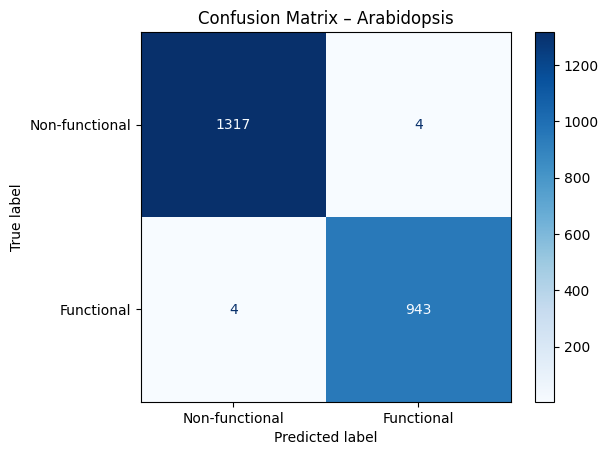

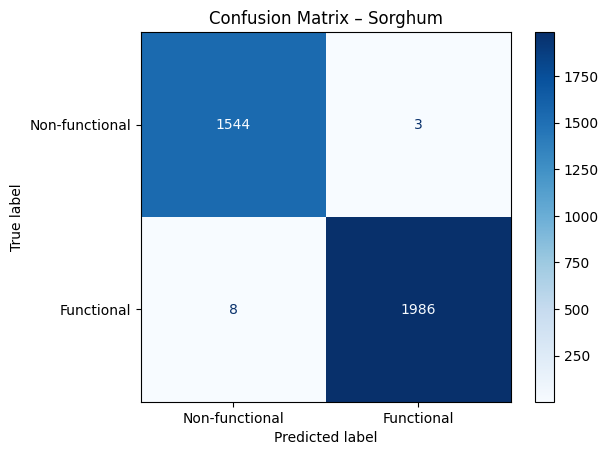

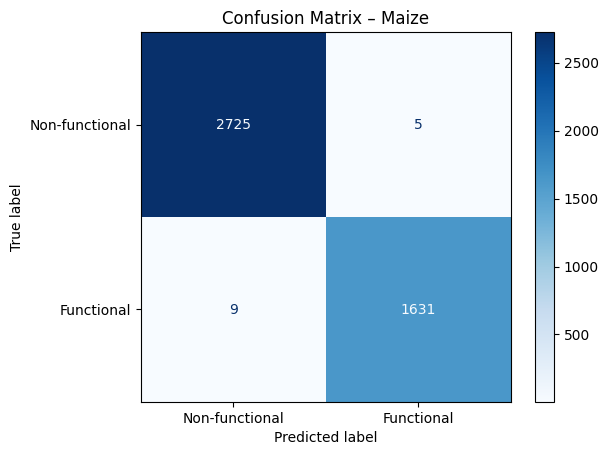

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for sp in output_df["Species"].unique():
    sub = output_df[output_df["Species"] == sp]

    y_t = sub["True_Label"].map({"Non-functional": 0, "Functional": 1})
    y_p = sub["Predicted_Label"].map({"Non-functional": 0, "Functional": 1})

    cm = confusion_matrix(y_t, y_p)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-functional", "Functional"]
    )
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix – {sp}")
    plt.show()


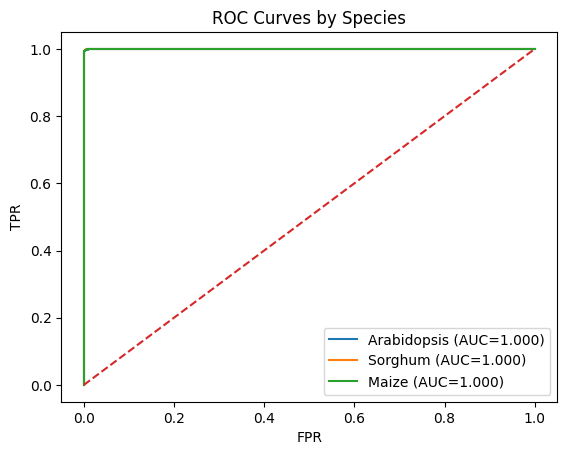

In [ ]:
for sp in output_df["Species"].unique():
    sub = output_df[output_df["Species"] == sp]
    y_t = sub["True_Label"].map({"Non-functional":0,"Functional":1})
    y_p = sub["Probability"]

    fpr, tpr, _ = roc_curve(y_t, y_p)
    auc = roc_auc_score(y_t, y_p)

    plt.plot(fpr, tpr, label=f"{sp} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],"--")
plt.legend()
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curves by Species")
plt.show()


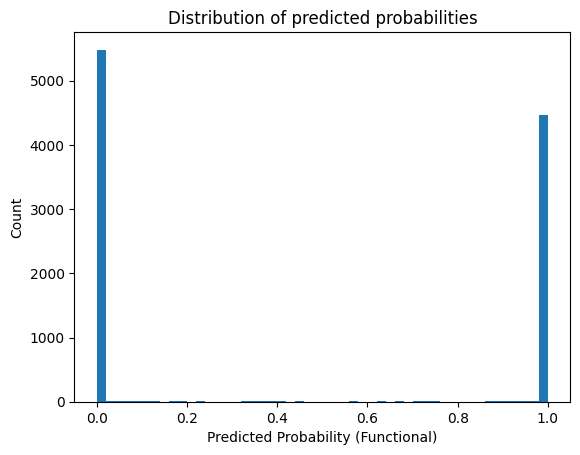

In [ ]:
import matplotlib.pyplot as plt

plt.hist(probs, bins=50)
plt.xlabel("Predicted Probability (Functional)")
plt.ylabel("Count")
plt.title("Distribution of predicted probabilities")
plt.show()


In [ ]:
from torch.utils.data import Dataset, DataLoader

class FullDataset(Dataset):
    def __init__(self, X_seq, X_gen, X_expr):
        self.X_seq = torch.tensor(X_seq, dtype=torch.float32)
        self.X_gen = torch.tensor(X_gen, dtype=torch.float32)
        self.X_expr = torch.tensor(X_expr, dtype=torch.float32)

    def __len__(self):
        return len(self.X_seq)

    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_gen[idx], self.X_expr[idx]


In [ ]:
full_ds = FullDataset(X_seq, X_gen, X_expr)
full_loader = DataLoader(
    full_ds,
    batch_size=64,      # safe on T4
    shuffle=False
)

In [ ]:
model.eval()
all_probs = []

with torch.no_grad():
    for seq_b, gen_b, expr_b in full_loader:
        seq_b = seq_b.to(device)
        gen_b = gen_b.to(device)
        expr_b = expr_b.to(device)

        probs = model(seq_b, gen_b, expr_b)
        all_probs.append(probs.cpu().numpy())


In [ ]:
all_probs = np.concatenate(all_probs).ravel()
print("Total samples:", len(all_probs))


Total samples: 67860


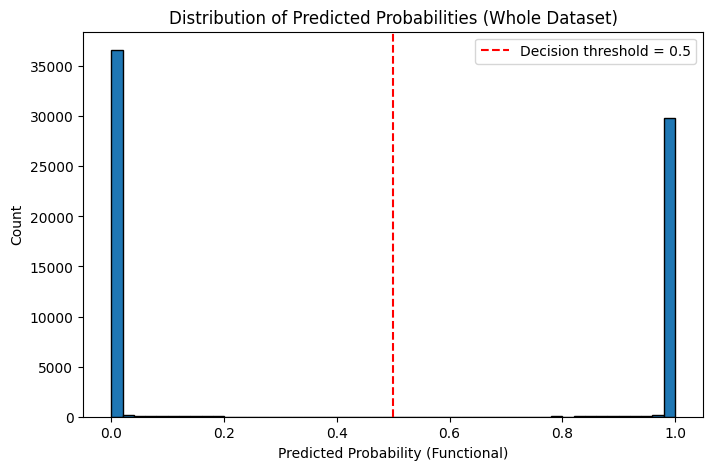

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(all_probs, bins=50, edgecolor="black")
plt.axvline(0.5, color="red", linestyle="--", label="Decision threshold = 0.5")
plt.xlabel("Predicted Probability (Functional)")
plt.ylabel("Count")
plt.title("Distribution of Predicted Probabilities (Whole Dataset)")
plt.legend()
plt.show()


In [ ]:
print("Prob < 0.1 :", np.sum(all_probs < 0.1))
print("Prob 0.1–0.9:", np.sum((all_probs >= 0.1) & (all_probs <= 0.9)))
print("Prob > 0.9 :", np.sum(all_probs > 0.9))


Prob < 0.1 : 36992
Prob 0.1–0.9: 659
Prob > 0.9 : 30209


In [ ]:
print("Predicted Non-functional:", np.sum(all_probs < 0.5))
print("Predicted Functional    :", np.sum(all_probs >= 0.5))


Predicted Non-functional: 37323
Predicted Functional    : 30537


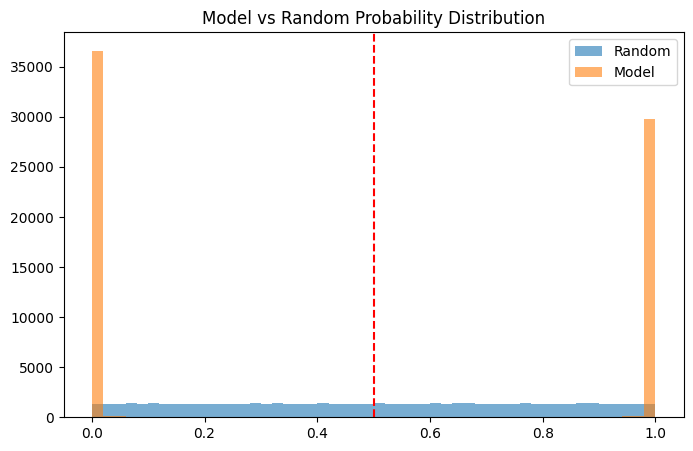

In [ ]:
random_probs = np.random.rand(len(all_probs))

plt.figure(figsize=(8,5))
plt.hist(random_probs, bins=50, alpha=0.6, label="Random")
plt.hist(all_probs, bins=50, alpha=0.6, label="Model")
plt.axvline(0.5, color="red", linestyle="--")
plt.legend()
plt.title("Model vs Random Probability Distribution")
plt.show()
